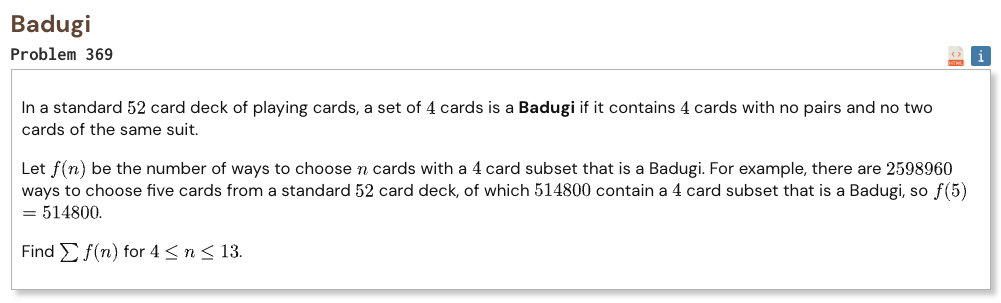

## Initial approach

* count hands that do not contain any Badugi
* process the deck rank by rank
* for each rank, choose any subset of its four suits
* track which suit combinations can be formed using different ranks
* if all four suits become reachable, the hand contains a Badugi
* keep only states where full four-suit mask is not reachable
* subtract those from all possible hands

In [1]:
from math import comb

def count_no_badugi(max_cards):
    dp = {(0, 1): 1}

    for _ in range(13):
        new_dp = {}

        for (cards, reachable), ways in dp.items():
            for chosen in range(16):
                added = chosen.bit_count()
                new_cards = cards + added

                if new_cards > max_cards:
                    continue

                new_reachable = reachable

                for mask in range(16):
                    if (reachable >> mask) & 1:
                        for suit in range(4):
                            if (chosen >> suit) & 1:
                                new_reachable |= 1 << (mask | (1 << suit))

                if (new_reachable >> 15) & 1:
                    continue

                key = (new_cards, new_reachable)
                new_dp[key] = new_dp.get(key, 0) + ways

        dp = new_dp

    result = [0] * (max_cards + 1)

    for (cards, reachable), ways in dp.items():
        result[cards] += ways

    return result

def solve():
    no_badugi = count_no_badugi(13)
    total = 0

    for n in range(4, 14):
        total += comb(52, n) - no_badugi[n]

    return total

no_badugi = count_no_badugi(13)
assert comb(52, 5) - no_badugi[5] == 514800

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 862400558448
CPU times: user 129 ms, sys: 1.34 ms, total: 131 ms
Wall time: 130 ms
